# Set up and read data

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .appName("01_EDA_Structure") \
    .getOrCreate()

df = spark.read.json(
    "hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/*/*/*"
)

26/04/08 12:13:39 WARN Utils: Your hostname, ax2 resolves to a loopback address: 127.0.1.1; using 192.168.40.130 instead (on interface ens33)
26/04/08 12:13:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 12:13:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/08 12:13:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/08 12:13:44 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/08 12:14:03 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                              

In [2]:
df.show(5)

+---------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+------------------+--------------------+------+-------+-----------+-------------------+------+----------+
|      _batch_id|                 _id|        _ingest_time|clusterID|      connectionTime|      disconnectTime|    doneChargingTime|      kWhDelivered|           sessionID|siteID|spaceID|  stationID|           timezone|userID|userInputs|
+---------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+------------------+--------------------+------+-------+-----------+-------------------+------+----------+
|20260407_141136|5bc940b4f9af8b0dc...|2026-04-07T14:17:...|     0039|2018-09-25 22:42:...|2018-09-25 22:54:...|2018-09-25 22:54:...|             1.342|2_39_139_28_2018-...|  0002| CA-303|2-39-139-28|America/Los_Angeles|  NULL|      NULL|
|20260407_141136|5bc940b4f9af8b0dc...|2026-04-07

In [3]:
# Số partition VẬT LÝ sau khi đọc
print(f"Physical partitions: {df.rdd.getNumPartitions()}")
# Output: physical partitions = số lượng file JSON

# Logical view: DataFrame là 1 bảng duy nhất
df.count()  # Gộp tất cả partitions lại

Physical partitions: 34


31424

# Phase 1: Hiểu cấu trúc tổng quan (Structure Discovery)

## Schema & Metadata

In [4]:
# 1. Schema chi tiết
print("=== SCHEMA ===")
df.printSchema()
print(f"\nTotal columns: {len(df.columns)}")

=== SCHEMA ===
root
 |-- _batch_id: string (nullable = true)
 |-- _id: string (nullable = true)
 |-- _ingest_time: string (nullable = true)
 |-- clusterID: string (nullable = true)
 |-- connectionTime: string (nullable = true)
 |-- disconnectTime: string (nullable = true)
 |-- doneChargingTime: string (nullable = true)
 |-- kWhDelivered: double (nullable = true)
 |-- sessionID: string (nullable = true)
 |-- siteID: string (nullable = true)
 |-- spaceID: string (nullable = true)
 |-- stationID: string (nullable = true)
 |-- timezone: string (nullable = true)
 |-- userID: string (nullable = true)
 |-- userInputs: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- WhPerMile: long (nullable = true)
 |    |    |-- kWhRequested: double (nullable = true)
 |    |    |-- milesRequested: long (nullable = true)
 |    |    |-- minutesAvailable: long (nullable = true)
 |    |    |-- modifiedAt: string (nullable = true)
 |    |    |-- paymentRequired: boolean (nul

In [5]:
# 2. Thống kê cơ bản về các cột
print("\n=== BASIC STATISTICS ===")
df.describe().show()


=== BASIC STATISTICS ===


26/04/08 12:24:06 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+-------+---------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+-----------------+--------------------+------+-----------+-----------+-------------------+------------------+
|summary|      _batch_id|                 _id|        _ingest_time|clusterID|      connectionTime|      disconnectTime|    doneChargingTime|     kWhDelivered|           sessionID|siteID|    spaceID|  stationID|           timezone|            userID|
+-------+---------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+-----------------+--------------------+------+-----------+-----------+-------------------+------------------+
|  count|          31424|               31424|               31424|    31424|               31424|               31424|               29369|            31424|               31424| 31424|      31424|      31424|              31424|             16388|


In [6]:
# 3. Null value analysis
from pyspark.sql.functions import col, sum as spark_sum

print("\n=== NULL COUNT PER COLUMN ===")
null_counts = df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
null_counts.show()


=== NULL COUNT PER COLUMN ===


[Stage 10:====================================================>   (32 + 2) / 34]

+---------+---+------------+---------+--------------+--------------+----------------+------------+---------+------+-------+---------+--------+------+----------+
|_batch_id|_id|_ingest_time|clusterID|connectionTime|disconnectTime|doneChargingTime|kWhDelivered|sessionID|siteID|spaceID|stationID|timezone|userID|userInputs|
+---------+---+------------+---------+--------------+--------------+----------------+------------+---------+------+-------+---------+--------+------+----------+
|        0|  0|           0|        0|             0|             0|            2055|           0|        0|     0|      0|        0|       0| 15036|     15036|
+---------+---+------------+---------+--------------+--------------+----------------+------------+---------+------+-------+---------+--------+------+----------+



In [7]:
# 4. Distinct counts
print("\n=== DISTINCT COUNTS ===")
distinct_counts = df.select([countDistinct(col(c)).alias(c) for c in df.columns])
distinct_counts.show()


=== DISTINCT COUNTS ===


[Stage 15:===========================================>              (3 + 1) / 4]

+---------+-----+------------+---------+--------------+--------------+----------------+------------+---------+------+-------+---------+--------+------+----------+
|_batch_id|  _id|_ingest_time|clusterID|connectionTime|disconnectTime|doneChargingTime|kWhDelivered|sessionID|siteID|spaceID|stationID|timezone|userID|userInputs|
+---------+-----+------------+---------+--------------+--------------+----------------+------------+---------+------+-------+---------+--------+------+----------+
|        1|31424|       31424|        2|         31380|         31386|           29253|       15642|    31424|     2|     55|       55|       1|   571|     16388|
+---------+-----+------------+---------+--------------+--------------+----------------+------------+---------+------+-------+---------+--------+------+----------+



## Data Quality Check

In [8]:
# 5. Kiểm tra data types thực tế
print("\n=== DATA TYPES SAMPLE ===")
df.sample(False, 0.01).show(10, vertical=True)


=== DATA TYPES SAMPLE ===
-RECORD 0--------------------------------
 _batch_id        | 20260407_141136      
 _id              | 5bc940b4f9af8b0dc... 
 _ingest_time     | 2026-04-07T14:17:... 
 clusterID        | 0039                 
 connectionTime   | 2018-09-25 21:34:... 
 disconnectTime   | 2018-09-25 22:26:... 
 doneChargingTime | 2018-09-25 22:21:... 
 kWhDelivered     | 2.375827359618296    
 sessionID        | 2_39_78_360_2018-... 
 siteID           | 0002                 
 spaceID          | CA-322               
 stationID        | 2-39-78-360          
 timezone         | America/Los_Angeles  
 userID           | NULL                 
 userInputs       | NULL                 
-RECORD 1--------------------------------
 _batch_id        | 20260407_141136      
 _id              | 5bc940b4f9af8b0dc... 
 _ingest_time     | 2026-04-07T14:17:... 
 clusterID        | 0039                 
 connectionTime   | 2018-09-25 09:18:... 
 disconnectTime   | 2018-09-25 16:53:... 
 doneCh

In [9]:
# 6. Phát hiện outliers trong kWhDelivered
df.select(
    min("kWhDelivered").alias("min_kWh"),
    max("kWhDelivered").alias("max_kWh"),
    mean("kWhDelivered").alias("mean_kWh"),
    stddev("kWhDelivered").alias("stddev_kWh"),
    expr("percentile_approx(kWhDelivered, 0.5)").alias("median_kWh"),
    expr("percentile_approx(kWhDelivered, 0.95)").alias("p95_kWh")
).show()

[Stage 20:====================================================>   (32 + 2) / 34]

+-------+-------+-----------------+-----------------+----------+-------+
|min_kWh|max_kWh|         mean_kWh|       stddev_kWh|median_kWh|p95_kWh|
+-------+-------+-----------------+-----------------+----------+-------+
|  0.501|   77.7|9.253283391408715|8.760917334027702|     6.716| 26.481|
+-------+-------+-----------------+-----------------+----------+-------+



# Phase 2: Hiểu Partition & Distribution (Spark Mechanism)

## Physical Partition Analysis

In [10]:
# 7. Số lượng partition vật lý
print(f"\n=== PHYSICAL PARTITIONS: {df.rdd.getNumPartitions()} ===")



=== PHYSICAL PARTITIONS: 34 ===


In [21]:
# 8. Phân bố dữ liệu giữa các partition
partition_sizes = df.rdd.glom().map(len).collect()
print(f"Partition sizes: {partition_sizes}")
print(f"Min/Max/Avg rows per partition: {__builtins__.min(partition_sizes)}/{__builtins__.max(partition_sizes)}/{__builtins__.sum(partition_sizes)/len(partition_sizes):.0f}")

[Stage 29:====================================================>   (32 + 2) / 34]

Partition sizes: [2907, 2633, 2341, 2089, 1885, 1589, 1523, 1423, 1411, 1292, 1225, 1196, 1221, 1128, 1065, 947, 799, 666, 560, 465, 421, 377, 337, 310, 288, 266, 247, 216, 186, 150, 112, 77, 44, 28]
Min/Max/Avg rows per partition: 28/2907/924


In [12]:
# 9. File gốc của mỗi partition (quan trọng!)
from pyspark.sql.functions import input_file_name, spark_partition_id

file_distribution = df.withColumn("file", input_file_name()) \
                      .withColumn("partition_id", spark_partition_id()) \
                      .groupBy("partition_id", "file") \
                      .count() \
                      .orderBy("partition_id")
file_distribution.show(20, truncate=False)

[Stage 24:====================================================>   (32 + 2) / 34]

+------------+-----------------------------------------------------------------------------------------------------------------------------+-----+
|partition_id|file                                                                                                                         |count|
+------------+-----------------------------------------------------------------------------------------------------------------------------+-----+
|0           |hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/year=2018/month=10/day=26/part_20260407_141136_20ac42b4.json|91   |
|0           |hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/year=2018/month=10/day=29/part_20260407_141136_f889855a.json|94   |
|0           |hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/year=2018/month=09/day=25/part_20260407_141136_bccb6824.json|104  |
|0           |hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/year=2018/month=11/day=05/part_20260407

##  Spark Execution Plan

In [13]:
# 10. Xem Logical Plan
print("=== LOGICAL PLAN ===")
print(df._jdf.queryExecution().logical().treeString())


=== LOGICAL PLAN ===
Relation [_batch_id#8,_id#9,_ingest_time#10,clusterID#11,connectionTime#12,disconnectTime#13,doneChargingTime#14,kWhDelivered#15,sessionID#16,siteID#17,spaceID#18,stationID#19,timezone#20,userID#21,userInputs#22] json



In [14]:
# 11. Xem Physical Plan (quan trọng để hiểu Spark đọc như nào)
print("\n=== PHYSICAL PLAN ===")
print(df._jdf.queryExecution().executedPlan().treeString())


=== PHYSICAL PLAN ===
FileScan json [_batch_id#8,_id#9,_ingest_time#10,clusterID#11,connectionTime#12,disconnectTime#13,doneChargingTime#14,kWhDelivered#15,sessionID#16,siteID#17,spaceID#18,stationID#19,timezone#20,userID#21,userInputs#22] Batched: false, DataFilters: [], Format: JSON, Location: InMemoryFileIndex(1084 paths)[hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/ye..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<_batch_id:string,_id:string,_ingest_time:string,clusterID:string,connectionTime:string,dis...



In [15]:
# 12. Xem optimized plan
print("\n=== OPTIMIZED PLAN ===")
print(df._jdf.queryExecution().optimizedPlan().treeString())


=== OPTIMIZED PLAN ===
Relation [_batch_id#8,_id#9,_ingest_time#10,clusterID#11,connectionTime#12,disconnectTime#13,doneChargingTime#14,kWhDelivered#15,sessionID#16,siteID#17,spaceID#18,stationID#19,timezone#20,userID#21,userInputs#22] json



# Phase 3: Time-based Analysis (ACN Dataset đặc thù)

## Parse Time Columns

In [28]:
from pyspark.sql.functions import to_timestamp, year, month, dayofmonth, hour, date_format, col, count, avg

# 13. Chuyển đổi string timestamps với timezone
df_clean = df.withColumn("connectionTime_ts", to_timestamp("connectionTime", "yyyy-MM-dd HH:mm:ssXXX")) \
             .withColumn("disconnectTime_ts", to_timestamp("disconnectTime", "yyyy-MM-dd HH:mm:ssXXX")) \
             .withColumn("doneChargingTime_ts", to_timestamp("doneChargingTime", "yyyy-MM-dd HH:mm:ssXXX"))

# 14. Tính duration
df_clean = df_clean.withColumn("session_duration_hours", 
                                (col("disconnectTime_ts").cast("long") - col("connectionTime_ts").cast("long")) / 3600) \
                   .withColumn("charging_duration_hours",
                                (col("doneChargingTime_ts").cast("long") - col("connectionTime_ts").cast("long")) / 3600)

# 15. Phân tích theo thời gian
df_clean.groupBy(
    year("connectionTime_ts").alias("year"),
    month("connectionTime_ts").alias("month"),
    hour("connectionTime_ts").alias("hour")
).agg(
    count("*").alias("num_sessions"),
    avg("kWhDelivered").alias("avg_kWh")
).orderBy("year", "month", "hour").show(20)

[Stage 33:====================================================>   (32 + 2) / 34]

+----+-----+----+------------+------------------+
|year|month|hour|num_sessions|           avg_kWh|
+----+-----+----+------------+------------------+
|2018|    4|   0|          14|11.328571428571427|
|2018|    4|   1|          11| 7.838909090909092|
|2018|    4|   2|           9| 8.254666666666667|
|2018|    4|   3|           9| 9.367222222222221|
|2018|    4|   4|           3|19.717333333333332|
|2018|    4|   5|           3|            17.059|
|2018|    4|   6|           3|            14.561|
|2018|    4|  11|           2|             6.282|
|2018|    4|  12|           1|             5.652|
|2018|    4|  13|           8|            7.7145|
|2018|    4|  14|          12| 9.442333333333332|
|2018|    4|  15|          54| 6.885592592592593|
|2018|    4|  16|          37| 9.603243243243245|
|2018|    4|  17|          21| 11.58947619047619|
|2018|    4|  18|          19| 9.705263830409356|
|2018|    4|  19|          13| 7.899692307692307|
|2018|    4|  20|          13| 3.325230769230769|


## Charging Behavior Patterns

In [29]:
# 16. Phân tích charging efficiency
df_clean.createOrReplaceTempView("sessions")

charging_stats = spark.sql("""
    SELECT 
        CASE 
            WHEN session_duration_hours < 1 THEN '<1h'
            WHEN session_duration_hours < 4 THEN '1-4h'
            WHEN session_duration_hours < 8 THEN '4-8h'
            ELSE '>8h'
        END AS duration_category,
        COUNT(*) AS num_sessions,
        AVG(kWhDelivered) AS avg_kwh,
        AVG(charging_duration_hours / session_duration_hours) AS avg_charging_efficiency
    FROM sessions
    WHERE session_duration_hours > 0
    GROUP BY duration_category
""")
charging_stats.show()

[Stage 36:====================================================>   (32 + 2) / 34]

+-----------------+------------+------------------+-----------------------+
|duration_category|num_sessions|           avg_kwh|avg_charging_efficiency|
+-----------------+------------+------------------+-----------------------+
|              <1h|        3664| 5.845148252790887|     0.9544575689797598|
|             4-8h|        8031|10.160015794245313|     0.5663470254024818|
|             1-4h|       10473| 7.649833107097597|     0.7900136452960809|
|              >8h|        9256|11.629944373291307|      0.443828232744811|
+-----------------+------------+------------------+-----------------------+



# Phase 4: Station & Site Analysis

 ## Usage Patterns

In [30]:
# 17. Top stations by energy delivered
print("\n=== TOP 10 STATIONS BY ENERGY ===")
df_clean.groupBy("stationID", "siteID") \
        .agg(
            count("*").alias("num_sessions"),
            sum("kWhDelivered").alias("total_kWh"),
            avg("kWhDelivered").alias("avg_kWh"),
            avg("session_duration_hours").alias("avg_duration_hours")
        ) \
        .orderBy(col("total_kWh").desc()) \
        .show(10)




=== TOP 10 STATIONS BY ENERGY ===


[Stage 39:====================================================>   (32 + 2) / 34]

+------------+------+------------+------------------+------------------+------------------+
|   stationID|siteID|num_sessions|         total_kWh|           avg_kWh|avg_duration_hours|
+------------+------+------------+------------------+------------------+------------------+
|2-39-81-4550|  0002|        1130| 25052.54800000001|   22.170396460177|0.8261715830875125|
| 2-39-139-28|  0002|        1717|14810.317890000002|  8.62569475247525| 4.938565488901833|
| 2-39-131-30|  0002|        1318|11987.729888611111|  9.09539445266397| 5.622922567863767|
| 2-39-129-17|  0002|        1064| 8708.512483611112|  8.18469218384503|4.7200707497911445|
| 2-39-79-377|  0002|         784| 8365.146710277779|10.669829987599208| 6.586415816326533|
| 2-39-79-379|  0002|         893|      8289.1468125| 9.282359252519596| 8.331520778897595|
| 2-39-91-437|  0002|         814| 8149.985465555556|10.012267156702158| 7.183084903084904|
| 2-39-127-19|  0002|         967| 7640.673572222221| 7.901420446972307|4.813655

In [31]:
# 18. Space utilization (nếu spaceID có ý nghĩa)
space_util = df_clean.filter(col("spaceID").isNotNull()) \
                     .groupBy("siteID", "spaceID") \
                     .agg(count("*").alias("sessions_count")) \
                     .withColumn("rank", row_number().over(Window.partitionBy("siteID").orderBy(col("sessions_count").desc())))
space_util.show(20)

[Stage 42:====================================================>   (32 + 2) / 34]

+------+--------+--------------+----+
|siteID| spaceID|sessions_count|rank|
+------+--------+--------------+----+
|  0002|  CA-303|          1717|   1|
|  0002|  CA-305|          1318|   2|
|  0002|11900388|          1130|   3|
|  0002|  CA-307|          1064|   4|
|  0002|  CA-315|          1024|   5|
|  0002|  CA-311|           991|   6|
|  0002|  CA-309|           967|   7|
|  0002|  CA-304|           938|   8|
|  0002|  CA-327|           893|   9|
|  0002|  CA-489|           859|  10|
|  0002|  CA-313|           855|  11|
|  0002|  CA-321|           826|  12|
|  0002|  CA-317|           814|  13|
|  0002|  CA-325|           784|  14|
|  0002|  CA-306|           723|  15|
|  0002|  CA-323|           717|  16|
|  0002|  CA-319|           698|  17|
|  0002|  CA-314|           657|  18|
|  0002|  CA-492|           641|  19|
|  0002|  CA-312|           618|  20|
+------+--------+--------------+----+
only showing top 20 rows



# Phase 5: Spark Performance Analysis

## Measure Read Performance

In [33]:
import time

# 19. Benchmark đọc với các format khác nhau
def benchmark_read(format_type, path):
    start = time.time()
    if format_type == "json":
        df_test = spark.read.json(path)
    elif format_type == "parquet":
        df_test = spark.read.parquet(path)
    count = df_test.count()
    elapsed = time.time() - start
    print(f"{format_type}: {count} rows in {elapsed:.2f}s")
    return elapsed

# 20. Cache và uncache để test
print("\n=== CACHE PERFORMANCE ===")
df.cache()
start = time.time()
df.count()
print(f"First count after cache: {time.time()-start:.2f}s")

start = time.time()
df.count()
print(f"Second count (cached): {time.time()-start:.2f}s")


=== CACHE PERFORMANCE ===


First count after cache: 4.59s
Second count (cached): 0.51s


## Shuffle Analysis

In [34]:
# 21. Operations gây shuffle
print("\n=== SHUFFLE OPERATIONS ===")

# GroupBy (gây shuffle)
shuffle_plan = df_clean.groupBy("siteID") \
                       .agg(count("*")) \
                       ._jdf.queryExecution().executedPlan().treeString()
print("GroupBy plan contains shuffle:", "Exchange" in shuffle_plan)

# Window operations (cũng gây shuffle)
window_spec = Window.partitionBy("siteID").orderBy("connectionTime_ts")
df_with_rank = df_clean.withColumn("rank", row_number().over(window_spec))
print("Window plan contains shuffle:", "Exchange" in df_with_rank._jdf.queryExecution().executedPlan().treeString())


=== SHUFFLE OPERATIONS ===
GroupBy plan contains shuffle: True
Window plan contains shuffle: True


# Phase 6: Data Quality & Anomalies

## Anomaly Detection

In [35]:
# 22. Phát hiện sessions bất thường
anomalies = df_clean.filter(
    (col("kWhDelivered") <= 0) |  # Zero energy
    (col("session_duration_hours") > 48) |  # Quá dài
    (col("charging_duration_hours") > col("session_duration_hours"))  # Charging > session
)

print(f"\n=== ANOMALIES COUNT: {anomalies.count()} ===")
anomalies.select("sessionID", "kWhDelivered", "session_duration_hours", "charging_duration_hours").show(10)




=== ANOMALIES COUNT: 1257 ===
+--------------------+------------------+----------------------+-----------------------+
|           sessionID|      kWhDelivered|session_duration_hours|charging_duration_hours|
+--------------------+------------------+----------------------+-----------------------+
|2_39_129_563_2018...|             0.725|    0.2738888888888889|     0.2902777777777778|
|2_39_78_363_2018-...| 16.07710125448172|     16.56861111111111|     16.585277777777776|
|2_39_79_377_2018-...|             13.21|     7.331944444444445|      7.348055555555556|
|2_39_78_362_2018-...|7.7788470728758075|     8.478333333333333|      8.493611111111111|
|2_39_90_26_2018-0...|            13.932|     7.811388888888889|      7.814444444444445|
|2_39_89_25_2018-0...|            13.961|    10.874722222222223|     10.875555555555556|
|2_39_123_23_2018-...|             4.669|    1.1111111111111112|                 1.1275|
|2_39_89_25_2018-1...|             11.67|    1.9158333333333333|     1.93194444

In [36]:
# 23. Duplicate sessions
duplicates = df_clean.groupBy("sessionID") \
                     .agg(count("*").alias("count")) \
                     .filter(col("count") > 1)
print(f"\n=== DUPLICATE SESSIONS: {duplicates.count()} ===")

[Stage 59:===================================================>    (31 + 3) / 34]


=== DUPLICATE SESSIONS: 0 ===


# Phase 7: Final Summary Report

## Create Summary DataFrame

In [38]:
# 24. Tổng hợp tất cả insights
summary = spark.createDataFrame([
    ("Total records", df.count()),
    ("Total stations", df.select("stationID").distinct().count()),
    ("Total sites", df.select("siteID").distinct().count()),
    ("Date range start", df.agg(min("connectionTime")).collect()[0][0]),
    ("Date range end", df.agg(max("connectionTime")).collect()[0][0]),
    ("Total energy (kWh)", df.agg(sum("kWhDelivered")).collect()[0][0]),
    ("Null percentage in userID", df.filter(col("userID").isNull()).count() / df.count() * 100),
    ("Physical partitions", df.rdd.getNumPartitions())
], ["Metric", "Value"])

print("\n=== FINAL SUMMARY ===")
summary.show(truncate=False)

# 25. Lưu lại kết quả EDA
summary.write.mode("overwrite").json("hdfs://localhost:9000/ev-project/data/silver/ev_sessions/caltech_eda_summary/")


=== FINAL SUMMARY ===
+-------------------------+-------------------------+
|Metric                   |Value                    |
+-------------------------+-------------------------+
|Total records            |31424                    |
|Total stations           |55                       |
|Total sites              |2                        |
|Date range start         |2018-04-25 04:08:04-07:00|
|Date range end           |2021-09-13 18:52:37-07:00|
|Total energy (kWh)       |290775.17729162745       |
|Null percentage in userID|47.848778004073324       |
|Physical partitions      |34                       |
+-------------------------+-------------------------+



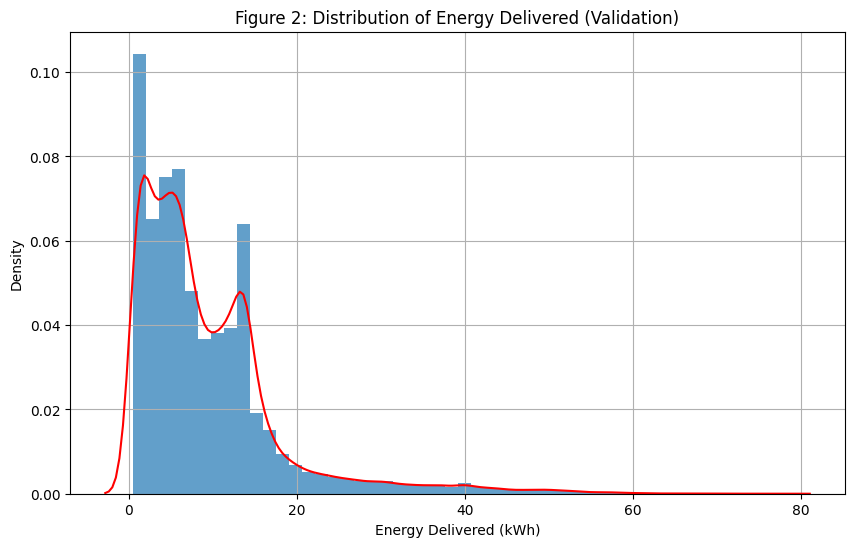

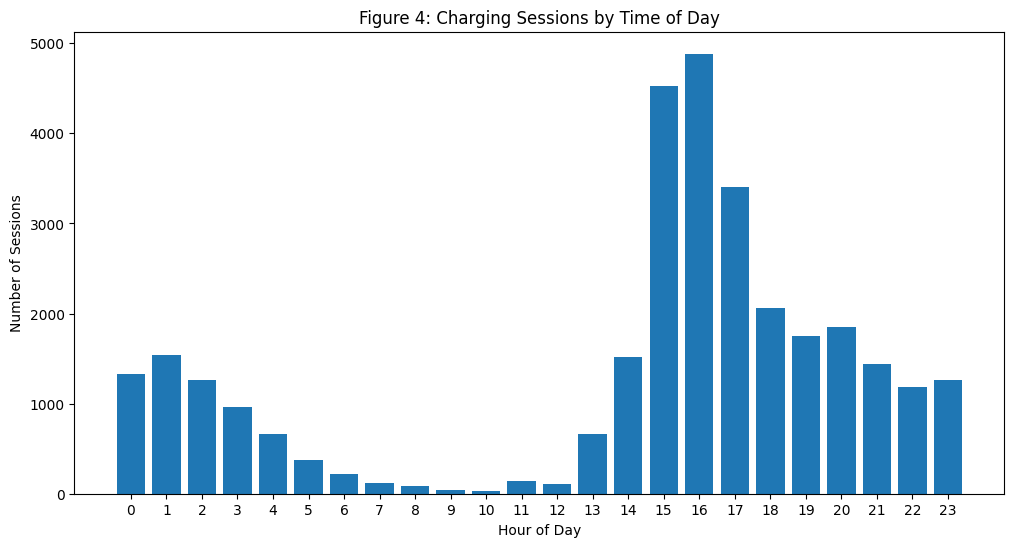

In [39]:
# Notebook: 07_Reproduce_Paper_Figures.ipynb
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 2: Histogram kWh delivered
fig, ax = plt.subplots(figsize=(10, 6))
df_clean.select("kWhDelivered").toPandas().hist(bins=50, density=True, alpha=0.7, ax=ax)
# Overlay KDE
pdf_kwh = df_clean.select("kWhDelivered").toPandas()
sns.kdeplot(pdf_kwh['kWhDelivered'], color='red', ax=ax)
ax.set_xlabel('Energy Delivered (kWh)')
ax.set_ylabel('Density')
ax.set_title('Figure 2: Distribution of Energy Delivered (Validation)')
plt.savefig('reproduced_fig2.png')

# Figure 4: Sessions by hour of day
hourly_dist = df_clean.withColumn("hour", hour("connectionTime_ts")) \
    .groupBy("hour").count() \
    .orderBy("hour").toPandas()

plt.figure(figsize=(12, 6))
plt.bar(hourly_dist['hour'], hourly_dist['count'])
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions')
plt.title('Figure 4: Charging Sessions by Time of Day')
plt.xticks(range(0, 24))
plt.savefig('reproduced_fig4.png')

IQR for kWhDelivered: Q1=3.38, Q3=12.68, IQR=9.30
Filtering range: [-10.57, 26.62]
Original: 31424, After IQR: 29864
Removed: 1560 outliers


Text(0.5, 1.0, 'After IQR Filtering - Should match paper')

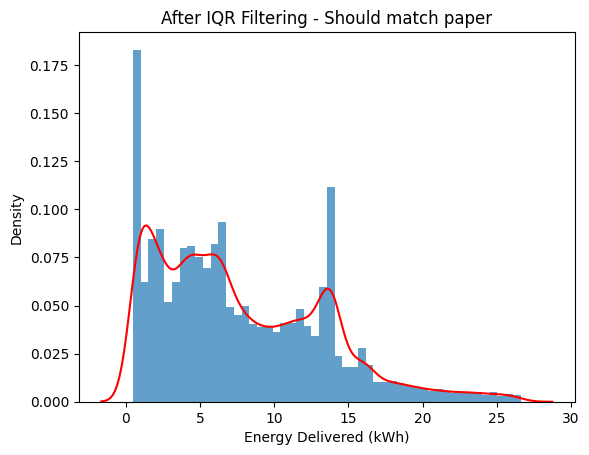

In [40]:
# Paper's preprocessing (từ methodology của họ):
"""
Outlier management employed the Interquartile Range (IQR) method, 
capping values between Q1—1.5 × IQR and Q3 + 1.5 × IQR
"""

# ✅ Bạn cần áp dụng IQR filtering để reproduce figure:
def apply_iqr_filter(df, column, multiplier=1.5):
    q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    
    print(f"IQR for {column}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"Filtering range: [{lower:.2f}, {upper:.2f}]")
    
    return df.filter((col(column) >= lower) & (col(column) <= upper))

# Apply filtering
df_filtered = apply_iqr_filter(df_clean, "kWhDelivered", multiplier=1.5)
print(f"Original: {df_clean.count()}, After IQR: {df_filtered.count()}")
print(f"Removed: {df_clean.count() - df_filtered.count()} outliers")

# Vẽ lại figure
pdf_filtered = df_filtered.select("kWhDelivered").toPandas()
plt.hist(pdf_filtered['kWhDelivered'], bins=50, density=True, alpha=0.7)
sns.kdeplot(pdf_filtered['kWhDelivered'], color='red')
plt.xlabel('Energy Delivered (kWh)')
plt.ylabel('Density')
plt.title('After IQR Filtering - Should match paper')